In [1]:
!wget -q https://raw.githubusercontent.com/alexanderparks/Spanish-Energy-Market-Prediction/main/energy_dataset.csv
!wget -q https://raw.githubusercontent.com/alexanderparks/Spanish-Energy-Market-Prediction/main/weather_features.csv

In [2]:
import pandas as pd
df=pd.read_csv('energy_dataset.csv')
df['time']=pd.to_datetime(df['time'],utc='true')
df=df.sort_values('time').reset_index(drop=True)

In [3]:
df['hour']=df['time'].dt.hour
df['dayofweek']=df['time'].dt.dayofweek
df['month']=df['time'].dt.month

In [4]:
print(df.groupby('hour')['price actual'].mean().round(2))
print(df.groupby('dayofweek')['price actual'].mean().round(2))
print(df.groupby('month')['price actual'].mean().round(2))

hour
0     50.55
1     48.77
2     47.77
3     47.82
4     50.35
5     53.88
6     58.46
7     60.98
8     61.78
9     62.64
10    62.09
11    61.61
12    60.32
13    58.16
14    57.01
15    57.30
16    59.30
17    62.90
18    65.64
19    66.80
20    64.32
21    59.98
22    57.03
23    53.74
Name: price actual, dtype: float64
dayofweek
0    59.46
1    60.10
2    59.91
3    60.07
4    59.68
5    54.64
6    51.35
Name: price actual, dtype: float64
month
1     61.63
2     53.31
3     47.87
4     48.29
5     51.89
6     58.21
7     60.39
8     59.02
9     60.85
10    63.48
11    63.85
12    65.40
Name: price actual, dtype: float64


In [5]:
p = df['price actual']
print(p.min(), p.max(), round(p.mean(), 2), round(p.std(), 2))
print((p <= 0).sum())      # any zero/negative prices?
print((p > 100).sum())     # how many extreme highs?

bins = [0,10,20,30,40,50,60,70,80,90,100,150,300]
print(pd.cut(p, bins=bins).value_counts().sort_index())

9.33 116.8 57.88 14.2
0
82
price actual
(0, 10]           4
(10, 20]        486
(20, 30]        903
(30, 40]       1918
(40, 50]       6016
(50, 60]      10253
(60, 70]       8377
(70, 80]       5551
(80, 90]       1320
(90, 100]       154
(100, 150]       82
(150, 300]        0
Name: count, dtype: int64


In [6]:
print(df['total load actual'].isna().sum())

36


In [7]:
missing_rows = df[df['total load actual'].isna()]
print(missing_rows[['time','total load actual']])

                           time  total load actual
108   2015-01-05 11:00:00+00:00                NaN
109   2015-01-05 12:00:00+00:00                NaN
110   2015-01-05 13:00:00+00:00                NaN
111   2015-01-05 14:00:00+00:00                NaN
112   2015-01-05 15:00:00+00:00                NaN
113   2015-01-05 16:00:00+00:00                NaN
661   2015-01-28 12:00:00+00:00                NaN
751   2015-02-01 06:00:00+00:00                NaN
752   2015-02-01 07:00:00+00:00                NaN
753   2015-02-01 08:00:00+00:00                NaN
756   2015-02-01 11:00:00+00:00                NaN
757   2015-02-01 12:00:00+00:00                NaN
758   2015-02-01 13:00:00+00:00                NaN
759   2015-02-01 14:00:00+00:00                NaN
760   2015-02-01 15:00:00+00:00                NaN
761   2015-02-01 16:00:00+00:00                NaN
762   2015-02-01 17:00:00+00:00                NaN
763   2015-02-01 18:00:00+00:00                NaN
2258  2015-04-05 01:00:00+00:00

In [8]:
df['total load actual'] = df['total load actual'].interpolate(method='linear')

In [9]:
print(df['total load actual'].isna().sum())

0


In [10]:
weather = pd.read_csv('weather_features.csv')
print(weather['city_name'].unique())
print(weather.shape)

['Valencia' 'Madrid' 'Bilbao' ' Barcelona' 'Seville']
(178396, 17)


In [11]:
weather['city_name'] = weather['city_name'].str.strip()
print(weather['city_name'].unique())

['Valencia' 'Madrid' 'Bilbao' 'Barcelona' 'Seville']


In [12]:
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)

In [13]:
weather_avg = weather.groupby('dt_iso').mean(numeric_only=True).reset_index()
print(weather_avg.shape)
print(weather_avg.head())

(35064, 13)
                     dt_iso        temp    temp_min    temp_max  pressure  \
0 2014-12-31 23:00:00+00:00  272.491463  272.491463  272.491463    1016.4   
1 2015-01-01 00:00:00+00:00  272.512700  272.512700  272.512700    1016.2   
2 2015-01-01 01:00:00+00:00  272.099137  272.099137  272.099137    1016.8   
3 2015-01-01 02:00:00+00:00  272.089469  272.089469  272.089469    1016.6   
4 2015-01-01 03:00:00+00:00  272.145900  272.145900  272.145900    1016.6   

   humidity  wind_speed  wind_deg  rain_1h  rain_3h  snow_3h  clouds_all  \
0      82.4         2.0     135.2      0.0      0.0      0.0         0.0   
1      82.4         2.0     135.8      0.0      0.0      0.0         0.0   
2      82.0         2.4     119.0      0.0      0.0      0.0         0.0   
3      82.0         2.4     119.2      0.0      0.0      0.0         0.0   
4      82.0         2.4     118.4      0.0      0.0      0.0         0.0   

   weather_id  
0       800.0  
1       800.0  
2       800.0  
3   

In [14]:
merged = df.merge(weather_avg, left_on='time', right_on='dt_iso', how='left')
print(merged.shape)
print(merged[['time','dt_iso','price actual','temp']].head())

(35064, 45)
                       time                    dt_iso  price actual  \
0 2014-12-31 23:00:00+00:00 2014-12-31 23:00:00+00:00         65.41   
1 2015-01-01 00:00:00+00:00 2015-01-01 00:00:00+00:00         64.92   
2 2015-01-01 01:00:00+00:00 2015-01-01 01:00:00+00:00         64.48   
3 2015-01-01 02:00:00+00:00 2015-01-01 02:00:00+00:00         59.32   
4 2015-01-01 03:00:00+00:00 2015-01-01 03:00:00+00:00         56.04   

         temp  
0  272.491463  
1  272.512700  
2  272.099137  
3  272.089469  
4  272.145900  


In [15]:
weather_cols = ['temp', 'pressure', 'humidity', 'wind_speed', 'clouds_all', 'rain_1h']
correlations = merged[weather_cols + ['price actual']].corr()['price actual']
print(correlations)

temp            0.080356
pressure       -0.016237
humidity       -0.039439
wind_speed     -0.225336
clouds_all     -0.097277
rain_1h        -0.072874
price actual    1.000000
Name: price actual, dtype: float64


In [16]:
del merged
del weather
del weather_avg

In [17]:
df['price_lag_24'] = df['price actual'].shift(24)
df['price_lag_168'] = df['price actual'].shift(168)
df['price_rollavg_24'] = df['price actual'].rolling(window=24).mean()
df['price_rollavg_168'] = df['price actual'].rolling(window=168).mean()

In [18]:
print(df.columns.tolist())

['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind offshore eday ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual', 'hour', 'dayofweek', 'month', 'price_lag_24', 'price_lag_168', 'price_rollavg_24', 'price_rollavg_168']


In [19]:
tertiles = df['price actual'].quantile([1/3, 2/3])

def price_tier(p):
    if p <= tertiles.iloc[0]:
        return 'LOW'
    elif p <= tertiles.iloc[1]:
        return 'MEDIUM'
    else:
        return 'HIGH'

df['price_tier'] = df['price actual'].apply(price_tier)
print(df['price_tier'].value_counts())

price_tier
LOW       11691
MEDIUM    11690
HIGH      11683
Name: count, dtype: int64


In [20]:
df['target'] = df['price_tier'].shift(-24)

In [21]:
print(df.shape)
print(df[['time','price actual','price_lag_24','price_lag_168','price_rollavg_168','target']].head(10))
print(df[['price_lag_24','price_lag_168','price_rollavg_168','target']].isna().sum())

(35064, 38)
                       time  price actual  price_lag_24  price_lag_168  \
0 2014-12-31 23:00:00+00:00         65.41           NaN            NaN   
1 2015-01-01 00:00:00+00:00         64.92           NaN            NaN   
2 2015-01-01 01:00:00+00:00         64.48           NaN            NaN   
3 2015-01-01 02:00:00+00:00         59.32           NaN            NaN   
4 2015-01-01 03:00:00+00:00         56.04           NaN            NaN   
5 2015-01-01 04:00:00+00:00         53.63           NaN            NaN   
6 2015-01-01 05:00:00+00:00         51.73           NaN            NaN   
7 2015-01-01 06:00:00+00:00         51.43           NaN            NaN   
8 2015-01-01 07:00:00+00:00         48.98           NaN            NaN   
9 2015-01-01 08:00:00+00:00         54.20           NaN            NaN   

   price_rollavg_168  target  
0                NaN  MEDIUM  
1                NaN  MEDIUM  
2                NaN  MEDIUM  
3                NaN  MEDIUM  
4                N

In [22]:
df_clean = df.dropna(subset=['price_lag_24', 'price_lag_168', 'price_rollavg_168', 'target'])
print(df.shape)
print(df_clean.shape)

(35064, 38)
(34872, 38)


In [23]:
print(df_clean[['price_lag_24','price_lag_168','price_rollavg_24','price_rollavg_168','target']].isna().sum())

price_lag_24         0
price_lag_168        0
price_rollavg_24     0
price_rollavg_168    0
target               0
dtype: int64


In [24]:
print(df_clean.columns.tolist())

['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind offshore eday ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual', 'hour', 'dayofweek', 'month', 'price_lag_24', 'price_lag_168', 'price_rollavg_24', 'price_rollavg_168', 'price_tier', 'target']


In [25]:
bucket4_cols = ['forecast solar day ahead', 'forecast wind offshore eday ahead',
                'forecast wind onshore day ahead', 'total load forecast', 'price day ahead']
print(df_clean[bucket4_cols + ['price actual']].corr()['price actual'])

forecast solar day ahead             0.100422
forecast wind offshore eday ahead         NaN
forecast wind onshore day ahead     -0.224020
total load forecast                  0.438129
price day ahead                      0.738034
price actual                         1.000000
Name: price actual, dtype: float64


In [26]:
print(df_clean['forecast wind offshore eday ahead'].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: forecast wind offshore eday ahead, dtype: float64


In [27]:
feature_cols = ['hour', 'dayofweek', 'month', 'price_lag_24', 'price_lag_168',
                 'price_rollavg_24', 'price_rollavg_168', 'total load forecast']

X = df_clean[feature_cols]
y = df_clean['target']

print(X.shape)
print(y.shape)
print(X.isna().sum())
print(y.isna().sum())

(34872, 8)
(34872,)
hour                   0
dayofweek              0
month                  0
price_lag_24           0
price_lag_168          0
price_rollavg_24       0
price_rollavg_168      0
total load forecast    0
dtype: int64
0


In [28]:
train_df = df_clean[df_clean['time'] < '2018-01-01']
test_df = df_clean[df_clean['time'] >= '2018-01-01']

print(train_df.shape)
print(test_df.shape)

(26137, 38)
(8735, 38)


In [29]:
feature_cols = ['hour', 'dayofweek', 'month', 'price_lag_24', 'price_lag_168',
                 'price_rollavg_24', 'price_rollavg_168', 'total load forecast']

X_train = train_df[feature_cols]
y_train = train_df['target']

X_test = test_df[feature_cols]
y_test = test_df['target']

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(26137, 8) (26137,)
(8735, 8) (8735,)


In [30]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    tr_dates = train_df.iloc[tr_idx]['time']
    val_dates = train_df.iloc[val_idx]['time']
    print(f"Fold {fold+1}:")
    print(f"  train: {tr_dates.min()} to {tr_dates.max()}  ({len(tr_idx)} rows)")
    print(f"  val:   {val_dates.min()} to {val_dates.max()}  ({len(val_idx)} rows)")

Fold 1:
  train: 2015-01-07 23:00:00+00:00 to 2015-07-08 11:00:00+00:00  (4357 rows)
  val:   2015-07-08 12:00:00+00:00 to 2016-01-05 23:00:00+00:00  (4356 rows)
Fold 2:
  train: 2015-01-07 23:00:00+00:00 to 2016-01-05 23:00:00+00:00  (8713 rows)
  val:   2016-01-06 00:00:00+00:00 to 2016-07-05 11:00:00+00:00  (4356 rows)
Fold 3:
  train: 2015-01-07 23:00:00+00:00 to 2016-07-05 11:00:00+00:00  (13069 rows)
  val:   2016-07-05 12:00:00+00:00 to 2017-01-02 23:00:00+00:00  (4356 rows)
Fold 4:
  train: 2015-01-07 23:00:00+00:00 to 2017-01-02 23:00:00+00:00  (17425 rows)
  val:   2017-01-03 00:00:00+00:00 to 2017-07-03 11:00:00+00:00  (4356 rows)
Fold 5:
  train: 2015-01-07 23:00:00+00:00 to 2017-07-03 11:00:00+00:00  (21781 rows)
  val:   2017-07-03 12:00:00+00:00 to 2017-12-31 23:00:00+00:00  (4356 rows)


In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
baseline_scores=[]
for fold,(train_idx,val_idx) in enumerate(tscv.split(X_train)):
    X_tr,X_val=X_train.iloc[train_idx],X_train.iloc[val_idx]
    y_tr,y_val=y_train.iloc[train_idx],y_train.iloc[val_idx]
    baseline=DummyClassifier(strategy='most_frequent')
    baseline.fit(X_tr,y_tr)
    pred=baseline.predict(X_val)
    acc = accuracy_score(y_val, pred)
    baseline_scores.append(acc)
    print(f"Fold {fold+1} baseline accuracy: {acc:.4f}")

print(f"\nMean baseline accuracy: {sum(baseline_scores)/len(baseline_scores):.4f}")


Fold 1 baseline accuracy: 0.4355
Fold 2 baseline accuracy: 0.0142
Fold 3 baseline accuracy: 0.4401
Fold 4 baseline accuracy: 0.3287
Fold 5 baseline accuracy: 0.2188

Mean baseline accuracy: 0.2875


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Logistic Regression, now with scaling via a Pipeline ---
logreg_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ])

    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_val)

    acc = accuracy_score(y_val, preds)
    logreg_scores.append(acc)
    print(f"Fold {fold+1} LogReg accuracy: {acc:.4f}")

print(f"\nMean LogReg accuracy: {sum(logreg_scores)/len(logreg_scores):.4f}")

Fold 1 LogReg accuracy: 0.5764
Fold 2 LogReg accuracy: 0.8540
Fold 3 LogReg accuracy: 0.7075
Fold 4 LogReg accuracy: 0.6141
Fold 5 LogReg accuracy: 0.6864

Mean LogReg accuracy: 0.6877


In [33]:
from sklearn.tree import DecisionTreeClassifier

# --- Decision Tree: try a few max_depth values, compare mean CV accuracy for each ---
depth_values = [3, 5, 7, 10, 15, None]  # None = no limit, tree grows until pure or too small to split

for depth in depth_values:
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))
        ])

        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_val)

        acc = accuracy_score(y_val, preds)
        fold_scores.append(acc)

    mean_acc = sum(fold_scores) / len(fold_scores)
    print(f"max_depth={depth}: fold scores = {[round(s, 4) for s in fold_scores]}, mean = {mean_acc:.4f}")

max_depth=3: fold scores = [0.6006, 0.3131, 0.6341, 0.6185, 0.6862], mean = 0.5705
max_depth=5: fold scores = [0.6173, 0.5223, 0.6997, 0.5758, 0.708], mean = 0.6246
max_depth=7: fold scores = [0.6049, 0.5615, 0.7163, 0.6093, 0.7215], mean = 0.6427
max_depth=10: fold scores = [0.5898, 0.5321, 0.6873, 0.6031, 0.7075], mean = 0.6240
max_depth=15: fold scores = [0.6031, 0.5877, 0.6648, 0.562, 0.6717], mean = 0.6179
max_depth=None: fold scores = [0.5994, 0.6049, 0.6607, 0.5455, 0.6566], mean = 0.6134


In [34]:
from sklearn.ensemble import RandomForestClassifier

# --- Random Forest: try a few n_estimators values, compare mean CV accuracy for each ---
n_estimators_values = [50, 100, 200, 300]

for n_est in n_estimators_values:
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestClassifier(n_estimators=n_est, max_depth=7, random_state=42))
        ])

        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_val)

        acc = accuracy_score(y_val, preds)
        fold_scores.append(acc)

    mean_acc = sum(fold_scores) / len(fold_scores)
    print(f"n_estimators={n_est}: fold scores = {[round(s, 4) for s in fold_scores]}, mean = {mean_acc:.4f}")

n_estimators=50: fold scores = [0.6451, 0.6497, 0.7257, 0.6715, 0.7509], mean = 0.6886
n_estimators=100: fold scores = [0.6561, 0.7254, 0.7264, 0.6827, 0.7495], mean = 0.7080
n_estimators=200: fold scores = [0.6586, 0.7339, 0.7362, 0.6814, 0.7518], mean = 0.7124
n_estimators=300: fold scores = [0.6596, 0.7339, 0.7406, 0.6843, 0.7534], mean = 0.7144


In [35]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# --- XGBoost needs numeric labels (0,1,2), not text (LOW/MEDIUM/HIGH) ---
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# --- XGBoost: early_stopping_rounds goes in the constructor (XGBoost 3.4+) ---
n_estimators_values = [100, 300, 500]

for n_est in n_estimators_values:
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr = y_train_encoded[train_idx]
        y_val = y_train_encoded[val_idx]

        model = XGBClassifier(
            n_estimators=n_est,
            max_depth=7,
            early_stopping_rounds=20,
            eval_metric='mlogloss',
            random_state=42
        )

        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val)

        acc = accuracy_score(y_val, preds)
        fold_scores.append(acc)

    mean_acc = sum(fold_scores) / len(fold_scores)
    print(f"n_estimators={n_est}: fold scores = {[round(s, 4) for s in fold_scores]}, mean = {mean_acc:.4f}")

{'HIGH': np.int64(0), 'LOW': np.int64(1), 'MEDIUM': np.int64(2)}
n_estimators=100: fold scores = [0.6568, 0.6915, 0.7638, 0.6949, 0.7514], mean = 0.7117
n_estimators=300: fold scores = [0.6568, 0.6915, 0.7638, 0.6949, 0.7514], mean = 0.7117
n_estimators=500: fold scores = [0.6568, 0.6915, 0.7638, 0.6949, 0.7514], mean = 0.7117


In [36]:
import numpy as np

# --- Re-run both finalists in the same loop, so fold-by-fold comparison is apples-to-apples ---
rf_scores = []
xgb_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]          # text labels, for RF
    y_tr_enc = y_train_encoded[train_idx]                                  # numeric labels, for XGBoost
    y_val_enc = y_train_encoded[val_idx]

    # Random Forest
    rf_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=300, max_depth=7, random_state=42))
    ])
    rf_pipe.fit(X_tr, y_tr)
    rf_preds = rf_pipe.predict(X_val)
    rf_acc = accuracy_score(y_val, rf_preds)
    rf_scores.append(rf_acc)

    # XGBoost
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=7,
        early_stopping_rounds=20,
        eval_metric='mlogloss',
        random_state=42
    )
    xgb_model.fit(X_tr, y_tr_enc, eval_set=[(X_val, y_val_enc)], verbose=False)
    xgb_preds = xgb_model.predict(X_val)
    xgb_acc = accuracy_score(y_val_enc, xgb_preds)
    xgb_scores.append(xgb_acc)

    print(f"Fold {fold+1}:  RF = {rf_acc:.4f}   XGB = {xgb_acc:.4f}   (diff = {rf_acc - xgb_acc:+.4f})")

# --- Summary: mean and variability for each ---
print("\n--- Summary ---")
print(f"Random Forest: mean = {np.mean(rf_scores):.4f}, std dev = {np.std(rf_scores):.4f}, variance = {np.var(rf_scores):.6f}")
print(f"XGBoost:       mean = {np.mean(xgb_scores):.4f}, std dev = {np.std(xgb_scores):.4f}, variance = {np.var(xgb_scores):.6f}")

wins_rf = sum(1 for r, x in zip(rf_scores, xgb_scores) if r > x)
wins_xgb = sum(1 for r, x in zip(rf_scores, xgb_scores) if x > r)
print(f"\nFold wins — Random Forest: {wins_rf}/5,   XGBoost: {wins_xgb}/5")

Fold 1:  RF = 0.6596   XGB = 0.6568   (diff = +0.0028)
Fold 2:  RF = 0.7339   XGB = 0.6915   (diff = +0.0425)
Fold 3:  RF = 0.7406   XGB = 0.7638   (diff = -0.0232)
Fold 4:  RF = 0.6843   XGB = 0.6949   (diff = -0.0106)
Fold 5:  RF = 0.7534   XGB = 0.7514   (diff = +0.0021)

--- Summary ---
Random Forest: mean = 0.7144, std dev = 0.0361, variance = 0.001301
XGBoost:       mean = 0.7117, std dev = 0.0400, variance = 0.001598

Fold wins — Random Forest: 3/5,   XGBoost: 2/5


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train final Random Forest on ALL of train_df (2015-2017), test ONCE on test_df (2018) ---
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=7, random_state=42))
])

final_pipe.fit(X_train, y_train)
final_preds = final_pipe.predict(X_test)

final_acc = accuracy_score(y_test, final_preds)
print(f"Final test accuracy (2018 holdout): {final_acc:.4f}")

# --- Confusion matrix ---
labels = ['LOW', 'MEDIUM', 'HIGH']
cm = confusion_matrix(y_test, final_preds, labels=labels)

Final test accuracy (2018 holdout): 0.7361


Confusion Matrix:
               pred_LOW  pred_MEDIUM  pred_HIGH
actual_LOW          857          551         16
actual_MEDIUM       390         1693        493
actual_HIGH          55          800       3880


<Axes: >

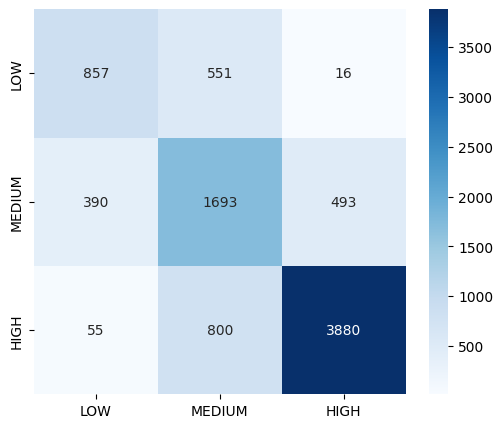

In [43]:
labels=['LOW','MEDIUM','HIGH']
cm=confusion_matrix(y_test,final_preds,labels=labels)
print("Confusion Matrix:")
print(pd.DataFrame(cm,index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels]))
plt.figure(figsize=(6,5))
plt.savefig('confusion_matrix.png')
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')

In [42]:
print("\nClassification Report:")
print(classification_report(y_test, final_preds, labels=labels))


Classification Report:
              precision    recall  f1-score   support

         LOW       0.66      0.60      0.63      1424
      MEDIUM       0.56      0.66      0.60      2576
        HIGH       0.88      0.82      0.85      4735

    accuracy                           0.74      8735
   macro avg       0.70      0.69      0.69      8735
weighted avg       0.75      0.74      0.74      8735

